# CogniNPC — Test 3: Propagacja i degradacja informacji w sieci agentow

Badanie stopniowego zniekształcania informacji przekazywanej autonomicznie
pomiedzy postaciami niezaleznymi przez podsystem opisany w podrozdziale 5.2.8.

**Zmienne niezalezne:** struktura informacji wprowadzanej, numer przekazania
w lancuchu, sumiennosc nadawcy.

**Zmienne zalezne:** podobienstwo do tresci zrodlowej, zachowanie elementow
rozpoznawalnych, wprowadzanie bytow nieistniejacych, dlugosc wypowiedzi
oraz — w warstwie jakosciowej — kategoria zniekształcenia.

Badanie ma charakter PRZEWAZNIE JAKOSCIOWY. Miary liczbowe pelnia role
pomocnicza: wskazuja miejsca warte przyjrzenia sie w transkryptach oraz
pozwalaja opisac tendencje, lecz materialem dowodowym pozostaja same
transkrypty lancuchow.

In [15]:
import json
import platform
import re
import subprocess
import time
import uuid
from itertools import product
from pathlib import Path

import httpx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from scipy import stats

sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

OUT = Path("results_test3")
(OUT / "figures").mkdir(parents=True, exist_ok=True)
(OUT / "tables").mkdir(parents=True, exist_ok=True)
(OUT / "transcripts").mkdir(parents=True, exist_ok=True)

API_BASE = "http://localhost:8000/api"

# ══════════════════════════════════════════════════════════════════════
# KONFIGURACJA WYMAGAJACA WERYFIKACJI
# Komorka kontrolna w sekcji 3 sprawdza poprawnosc tych ustawien
# PRZED uruchomieniem pelnego przebiegu.
# ══════════════════════════════════════════════════════════════════════

GOSSIP_URL = f"{API_BASE}/gossip"

# Nazwy pol w ciele zadania POST /api/gossip.
# Jesli backend uzywa innych nazw, komorka kontrolna wypisze blad 422
# wraz z lista pol oczekiwanych przez Pydantic.
FIELD_SOURCE = "npc_source"
FIELD_TARGET = "npc_target"

# Katalog profili widziany z hosta (montowany do kontenera jako /app/data).
PROFILES_DIR = Path("../data/npc_profiles")

# Czy endpoint plotki przyjmuje limit generowanych tokenow.
# Jesli nie — ustaw na None; podsystem i tak ogranicza wynik do jednego
# zdania regula promptu mutacyjnego (podrozdzial 5.2.8).
GOSSIP_NUM_PREDICT = None

# ══════════════════════════════════════════════════════════════════════
# PLAN EKSPERYMENTU
# ══════════════════════════════════════════════════════════════════════

CHAIN_LEN = 6          # liczba postaci; przekazan bedzie CHAIN_LEN - 1 = 5
REPS = 3               # powtorzen na kombinacje
COOLDOWN_S = 0.4
TIMEOUT_S = 300.0

# Warunki sumiennosci nadawcy. Dyrektywa plotkarska dla tej cechy odnosi
# sie wprost do wiernosci zachowania szczegolow (tabela 5.5).
CONS_LEVELS = {"niska": 20, "wysoka": 90}
NEUTRAL_LEVEL = 50

OCEAN_KEYS = ["openness", "conscientiousness", "extroversion",
              "agreeableness", "neuroticism"]

# ══════════════════════════════════════════════════════════════════════
# INFORMACJE WPROWADZANE
# ══════════════════════════════════════════════════════════════════════
# Trzy zdania o odmiennej strukturze skladniowej, dobrane tak, by byly
# podatne na rozne rodzaje zniekształcen:
#   S1 — sprawca + przedmiot + miejsce: podatne na przesuniecie sprawstwa
#   S2 — okreslenie ilosciowe: podatne na zmiane liczby
#   S3 — stan bez wskazania sprawcy: podatne na dopisanie sprawcy
#
# "entities" wymienia elementy rozpoznawalne, ktorych zachowanie podlega
# sledzeniu. Warianty fleksyjne i synonimy podano jawnie, aby zliczanie
# nie zaniżalo wyniku przy drobnej zmianie formy.

SEEDS = {
    "S1_sprawca": {
        "text": "Bran the miller stole a silver candlestick from the chapel last night.",
        "entities": {
            "sprawca":    ["bran", "miller"],
            "przedmiot":  ["candlestick", "candle stick", "candelabra"],
            "materiał":   ["silver"],
            "miejsce":    ["chapel", "church"],
            "czas":       ["last night", "yesterday night", "night"],
            "czynność":   ["stole", "stolen", "steal", "theft", "took"],
        },
    },
    "S2_liczba": {
        "text": "Seven horses went missing from the eastern stables during the storm.",
        "entities": {
            "liczba":     ["seven", "7"],
            "przedmiot":  ["horse", "horses"],
            "miejsce":    ["stable", "stables", "eastern"],
            "okoliczność":["storm", "storms", "tempest"],
            "czynność":   ["missing", "vanished", "disappeared", "gone"],
        },
    },
    "S3_stan": {
        "text": "The well in the market square has been dry for three days.",
        "entities": {
            "przedmiot":  ["well"],
            "miejsce":    ["market square", "market", "square"],
            "stan":       ["dry", "dried", "empty"],
            "czas":       ["three days", "3 days", "days"],
        },
    },
}

RUN_ID = uuid.uuid4().hex[:12]
RAW_PATH = OUT / f"raw_t3_{RUN_ID}.jsonl"
print(f"run_id = {RUN_ID}\nsurowe dane -> {RAW_PATH}")

run_id = eea2c39a9309
surowe dane -> results_test3/raw_t3_eea2c39a9309.jsonl


## 2. Profile lancuchowe

Manipulacje sumiennoscia nadawcy zrealizowano przez odrebne profile
postaci, nie przez nadpisanie wektora w zadaniu.

UZASADNIENIE: rozwiazanie to nie zalezy od tego, czy endpoint plotki
przyjmuje parametr nadpisania profilu, a jednoczesnie izoluje badana
ceche — postacie lancucha maja pozostale cztery wymiary na wartosci
srodkowej, pusta liste manieryzmow oraz tlo fabularne nienarzucajace
okreslonego stosunku do przekazywanych informacji.

In [16]:
CHAIN_NAMES = ["Alder", "Bryn", "Corwin", "Delia", "Ewan", "Fenn"]

def chain_id(band: str, pos: int) -> str:
    return f"chain_{band[:2]}_{pos}"


def write_chain_profiles(dry_run: bool = False) -> list[str]:
    created = []
    for band, level in CONS_LEVELS.items():
        for pos in range(1, CHAIN_LEN + 1):
            npc_id = chain_id(band, pos)
            ocean = {k: NEUTRAL_LEVEL for k in OCEAN_KEYS}
            ocean["conscientiousness"] = level
            profile = {
                "id": npc_id,
                "name": f"{CHAIN_NAMES[(pos-1) % len(CHAIN_NAMES)]} of Oakhaven",
                "profession": "Townsfolk",
                "backstory": ("You live in Oakhaven and know the people here by sight. "
                              "You take an ordinary interest in what happens around town."),
                "quirks": [],
                "ocean": ocean,
            }
            path = PROFILES_DIR / f"{npc_id}.yaml"
            if not dry_run:
                path.parent.mkdir(parents=True, exist_ok=True)
                with path.open("w", encoding="utf-8") as f:
                    yaml.safe_dump(profile, f, allow_unicode=True, sort_keys=False)
            created.append(npc_id)
    return created


WRITE_PROFILES = True   # ustaw False, jesli profile juz istnieja

if WRITE_PROFILES:
    if not PROFILES_DIR.exists():
        print(f"UWAGA: katalog {PROFILES_DIR} nie istnieje z poziomu tego notebooka.")
        print("Popraw stala PROFILES_DIR albo utworz profile recznie.")
    else:
        ids = write_chain_profiles()
        print(f"Zapisano {len(ids)} profili lancuchowych w {PROFILES_DIR}")
        print("  niska sumiennosc: ", [i for i in ids if "_ni_" in i])
        print("  wysoka sumiennosc:", [i for i in ids if "_wy_" in i])


Zapisano 12 profili lancuchowych w ../data/npc_profiles
  niska sumiennosc:  ['chain_ni_1', 'chain_ni_2', 'chain_ni_3', 'chain_ni_4', 'chain_ni_5', 'chain_ni_6']
  wysoka sumiennosc: ['chain_wy_1', 'chain_wy_2', 'chain_wy_3', 'chain_wy_4', 'chain_wy_5', 'chain_wy_6']


## 3. Kontrola wstepna

In [17]:
def api_wipe(client, npc_id):
    r = client.delete(f"{API_BASE}/memories/{npc_id}")
    r.raise_for_status()
    return r.json().get("deleted_memories", 0)


def api_inject(client, npc_id, fact, source="seed"):
    r = client.post(f"{API_BASE}/injectMemory",
                    json={"npc_id": npc_id, "fact": fact, "source": source})
    r.raise_for_status()


def api_memories(client, npc_id):
    r = client.get(f"{API_BASE}/memories/{npc_id}")
    r.raise_for_status()
    return r.json()


def api_gossip(client, source_id, target_id):
    payload = {FIELD_SOURCE: source_id, FIELD_TARGET: target_id}
    if GOSSIP_NUM_PREDICT is not None:
        payload["num_predict"] = GOSSIP_NUM_PREDICT
    r = client.post(GOSSIP_URL, json=payload, timeout=TIMEOUT_S)
    return r


def preflight():
    ok = True
    with httpx.Client(timeout=120.0) as c:
        a, b = chain_id("niska", 1), chain_id("niska", 2)

        # 1. profile widoczne dla backendu
        for npc in (a, b):
            r = c.get(f"{API_BASE}/npcProfiles/{npc}")
            if r.status_code != 200:
                print(f"  BLAD: backend nie widzi profilu '{npc}' (HTTP {r.status_code})")
                print("        sprawdz PROFILES_DIR oraz montowanie katalogu do kontenera")
                ok = False
            else:
                print(f"  profil '{npc}': OK")
        if not ok:
            return False

        # 2. czyszczenie i wstrzykniecie
        api_wipe(c, a); api_wipe(c, b)
        api_inject(c, a, SEEDS["S1_sprawca"]["text"])
        n = api_memories(c, a)["total_memories"]
        print(f"  pamiec nadawcy po wstrzyknieciu: {n} dokument(ow)"
              + ("" if n == 1 else "  <-- POWINIEN BYC DOKLADNIE 1"))
        if n != 1:
            ok = False

        # 3. wywolanie plotki
        r = api_gossip(c, a, b)
        if r.status_code != 200:
            print(f"  BLAD: /api/gossip zwrocil HTTP {r.status_code}")
            print(f"        wyslano: {{'{FIELD_SOURCE}': ..., '{FIELD_TARGET}': ...}}")
            print(f"        odpowiedz: {r.text[:400]}")
            print("        popraw stale FIELD_SOURCE / FIELD_TARGET wg schemas.py")
            return False
        print(f"  /api/gossip: OK")
        print(f"    klucze odpowiedzi: {list(r.json().keys())}")

        # 4. odczyt wyniku z pamieci odbiorcy
        mem = api_memories(c, b)
        print(f"  pamiec odbiorcy po przekazaniu: {mem['total_memories']} dokument(ow)")
        if mem["total_memories"] != 1:
            print("    <-- POWINIEN BYC DOKLADNIE 1; sprawdz czy podsystem nie zapisuje")
            print("        dodatkowych wpisow, co zaburzyloby kolejne przekazanie")
            ok = False
        else:
            m = mem["memories"][0]
            print(f"    tresc: {m['content'][:160]}")
            print(f"    metadane: {m.get('metadata')}")

        api_wipe(c, a); api_wipe(c, b)

    print("\n" + ("KONTROLA ZAKONCZONA POWODZENIEM" if ok else "KONTROLA NIEUDANA"))
    return ok


PREFLIGHT_OK = preflight()

  profil 'chain_ni_1': OK
  profil 'chain_ni_2': OK
  pamiec nadawcy po wstrzyknieciu: 1 dokument(ow)
  /api/gossip: OK
    klucze odpowiedzi: ['status', 'npc_source', 'npc_target', 'mutated_gossip']
  pamiec odbiorcy po przekazaniu: 1 dokument(ow)
    tresc: Some folks say Bran the miller was seen lurking around the chapel after dark yesterday, and there's rumors going 'round he might've pilfered a fine silver candl
    metadane: {'npc_id': 'chain_ni_2', 'source': 'gossip_from_chain_ni_1', 'timestamp': '2026-09-01T21:00:02.167402+00:00'}

KONTROLA ZAKONCZONA POWODZENIEM


## 4. Funkcja osadzajaca

Do wyznaczenia podobienstwa wykorzystano ten sam model osadzajacy,
ktorego uzywa baza wektorowa systemu (podrozdzial 5.3.3). Dzieki temu
miara nie wprowadza do badania dodatkowego komponentu, a jej wartosci
pozostaja porownywalne z tymi, na ktorych opiera sie mechanizm
wyszukiwania w samym systemie.

In [18]:
_EF = None
_EF_NAME = None

def get_embedder():
    global _EF, _EF_NAME
    if _EF is not None:
        return _EF

    try:
        try:
            from chromadb.utils import embedding_functions  # type: ignore
        except ImportError:
            import chromadb
            embedding_functions = chromadb.utils.embedding_functions  # type: ignore[attr-defined]

        ef = embedding_functions.ONNXMiniLM_L6_V2()
        _EF = lambda xs: np.asarray(ef(xs), dtype=float)
        _EF_NAME = "chromadb ONNXMiniLM_L6_V2"
    except Exception as exc:
        print(f"  ChromaDB EF niedostepne ({type(exc).__name__}), probuje sentence-transformers")
        try:
            from sentence_transformers import SentenceTransformer
            st = SentenceTransformer("all-MiniLM-L6-v2")
            _EF = lambda xs: np.asarray(st.encode(xs), dtype=float)
            _EF_NAME = "sentence-transformers all-MiniLM-L6-v2"
        except Exception as exc2:
            print(f"  sentence-transformers unavailable ({type(exc2).__name__}), using deterministic fallback")
            def _fallback(xs):
                xs = np.asarray(xs, dtype=object)
                if xs.ndim == 0:
                    xs = np.asarray([xs.item()], dtype=object)

                vectors = []
                for sentence in xs.tolist():
                    text = str(sentence).lower()
                    v = np.zeros(384, dtype=float)
                    for i, ch in enumerate(text):
                        v[i % len(v)] += (ord(ch) + 1) / 17.0
                    norm = np.linalg.norm(v)
                    if norm > 0:
                        v = v / norm
                    vectors.append(v)
                return np.vstack(vectors)

            _EF = _fallback
            _EF_NAME = "deterministic fallback embedding"

    print(f"  model osadzajacy: {_EF_NAME}")
    return _EF


def cosine(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(a @ b / (na * nb)) if na and nb else np.nan


_ = get_embedder()
if _EF is None:
    raise RuntimeError("Embedding function could not be initialized.")

_v = _EF(["The well is dry.", "The well is not dry."])
print(f"  kontrola: podobienstwo zdania i jego zaprzeczenia = {cosine(_v[0], _v[1]):.3f}")
print("  (wysoka wartosc potwierdza zastrzezenie z podrozdzialu 6.5.2 —")
print("   miara nie odroznia twierdzenia od jego zaprzeczenia)")

  model osadzajacy: chromadb ONNXMiniLM_L6_V2
  kontrola: podobienstwo zdania i jego zaprzeczenia = 0.933
  (wysoka wartosc potwierdza zastrzezenie z podrozdzialu 6.5.2 —
   miara nie odroznia twierdzenia od jego zaprzeczenia)


## 5. Miary zniekształcenia

In [19]:
RE_TOKEN = re.compile(r"[A-Za-z0-9']+")
RE_SENT_START = re.compile(r"(?:^|[.!?]\s+)([A-Z][a-z]+)")

# Wyrazy funkcyjne oraz zaimki pisane wielka litera na poczatku zdania —
# wykluczane z detekcji nazw wlasnych, aby nie generowac falszywych trafien.
STOP_CAPS = {
    "the", "a", "an", "i", "it", "he", "she", "they", "we", "you", "there",
    "this", "that", "these", "those", "some", "one", "seven", "three",
    "last", "no", "yes", "well", "but", "and", "if", "when", "what", "who",
    "his", "her", "their", "our", "my", "your", "someone", "somebody",
    "people", "folk", "everyone", "nobody",
}

# Wskazniki przypuszczenia — sluza do wykrycia przeksztalcenia
# stwierdzenia w domysl, wymienionego wsrod kategorii zniekształcen.
RE_HEDGE = re.compile(
    r"\b(?:maybe|perhaps|might|may have|could have|possibly|apparently|"
    r"supposedly|allegedly|rumou?r|they say|i heard|word is|seems|"
    r"reckon|suspect|probably|some say)\b", re.I)

# Wskazniki wzmocnienia emocjonalnego
RE_INTENS = re.compile(
    r"\b(?:terrible|awful|dreadful|shocking|outrageous|horrible|dangerous|"
    r"disaster|scandal|wicked|evil|cursed|worst|never|everyone|nobody)\b", re.I)


def proper_nouns(text: str, permissive: bool = False) -> set[str]:
    """Wyodrebnia wyrazy pisane wielka litera.

    W tekstach generowanych stosowane jest wykluczenie wyrazow stojacych
    na poczatku zdania i wystepujacych tylko raz — bez niego kazde zdanie
    dawaloby falszywe trafienie.

    Dla tresci ZRODLOWEJ stosowany jest wariant permissive=True. Wykluczenie
    poczatkow zdan usuwaloby z niej nazwy wlasne stojace na pierwszej pozycji
    (np. imie sprawcy), wskutek czego w tekstach pochodnych byłyby one
    zliczane jako nazwy nowo wprowadzone. Byłby to falszywy dowod naruszenia
    reguly promptu mutacyjnego zakazujacej wprowadzania nieistniejacych osob.
    """
    sent_starts = {m.group(1).lower() for m in RE_SENT_START.finditer(text)}
    out = set()
    for w in re.findall(r"\b([A-Z][a-z]{2,})\b", text):
        lw = w.lower()
        if lw in STOP_CAPS:
            continue
        if not permissive and lw in sent_starts and text.lower().count(lw) == 1:
            continue
        out.add(lw)
    return out


def entity_retention(text: str, entities: dict) -> dict:
    """Sprawdza, ktore elementy rozpoznawalne przetrwaly przekazanie."""
    low = text.lower()
    kept = {}
    for slot, variants in entities.items():
        kept[slot] = any(v in low for v in variants)
    return kept


def measure(text: str, seed: dict) -> dict:
    ents = entity_retention(text, seed["entities"])
    n_slots = len(ents)
    n_kept = sum(ents.values())
    seed_props = proper_nouns(seed["text"], permissive=True)
    new_props = proper_nouns(text) - seed_props

    return {
        "n_words": len(RE_TOKEN.findall(text)),
        "slots_total": n_slots,
        "slots_kept": n_kept,
        "slots_kept_frac": n_kept / n_slots if n_slots else np.nan,
        # Wprowadzenie bytu nieobecnego w tresci zrodlowej stanowi
        # bezposrednie naruszenie jednej z siedmiu regul promptu
        # mutacyjnego (podrozdzial 5.2.8).
        "n_new_proper": len(new_props),
        "new_proper": ", ".join(sorted(new_props)),
        "n_hedge": len(RE_HEDGE.findall(text)),
        "n_intens": len(RE_INTENS.findall(text)),
        **{f"slot_{k}": v for k, v in ents.items()},
    }


# kontrola dzialania
_probe_seed = SEEDS["S1_sprawca"]
_probe_txt = ("They say Bran the miller might have taken something silver "
              "from the shrine — Marta swears she saw him.")
_m = measure(_probe_txt, _probe_seed)
print(json.dumps({k: v for k, v in _m.items()
                  if k in ("slots_kept", "slots_total", "n_new_proper",
                           "new_proper", "n_hedge")}, indent=2))

{
  "slots_total": 6,
  "slots_kept": 2,
  "n_new_proper": 1,
  "new_proper": "marta",
  "n_hedge": 2
}


## 6. Przebieg lancucha

In [14]:
def run_chain(client, band: str, seed_key: str, rep: int) -> list[dict]:
    seed = SEEDS[seed_key]
    ids = [chain_id(band, i) for i in range(1, CHAIN_LEN + 1)]

    # Czyszczenie pamieci WSZYSTKICH postaci lancucha.
    # Krok konieczny: mechanizm losowania wybiera wspomnienie z jednakowym
    # prawdopodobienstwem sposrod wszystkich obecnych w pamieci nadawcy
    # (podrozdzial 5.2.8), wobec czego pamiec musi zawierac dokladnie jeden
    # dokument, aby wybor byl zdeterminowany.
    for npc in ids:
        api_wipe(client, npc)

    api_inject(client, ids[0], seed["text"], source="seed")

    recs = []
    prev_text = seed["text"]
    if _EF is None:
        get_embedder()
    prev_vec = _EF([seed["text"]])[0]
    seed_vec = prev_vec

    for step in range(1, CHAIN_LEN):
        src, tgt = ids[step - 1], ids[step]
        t0 = time.perf_counter()
        r = api_gossip(client, src, tgt)
        wall_ms = (time.perf_counter() - t0) * 1000

        if r.status_code != 200:
            recs.append({"ok": False, "step": step, "source": src, "target": tgt,
                         "error": f"HTTP {r.status_code}: {r.text[:200]}"})
            break

        mem = api_memories(client, tgt)
        if mem["total_memories"] != 1:
            recs.append({"ok": False, "step": step, "source": src, "target": tgt,
                         "error": f"odbiorca ma {mem['total_memories']} wspomnien"})
            break

        doc = mem["memories"][0]
        text = doc["content"]
        if _EF is None:
            get_embedder()
        vec = _EF([text])[0]

        rec = {
            "ok": True, "band": band, "cons_level": CONS_LEVELS[band],
            "seed_key": seed_key, "rep": rep, "step": step,
            "source": src, "target": tgt,
            "text": text, "prev_text": prev_text,
            "metadata": json.dumps(doc.get("metadata", {}), ensure_ascii=False),
            "wall_ms": round(wall_ms, 1),
            "cos_vs_seed": round(cosine(seed_vec, vec), 4),
            "cos_vs_prev": round(cosine(prev_vec, vec), 4),
        }
        rec.update(measure(text, seed))
        recs.append(rec)

        prev_text, prev_vec = text, vec
        time.sleep(COOLDOWN_S)

    return recs

## 7. Przebieg pomiarowy

In [20]:
RUN_MEASUREMENT = True

combos = list(product(CONS_LEVELS.keys(), SEEDS.keys(), range(REPS)))
print(f"Kombinacji: {len(combos)} | przekazan lacznie: {len(combos) * (CHAIN_LEN - 1)}")

if RUN_MEASUREMENT:
    if not PREFLIGHT_OK:
        raise RuntimeError("Kontrola wstepna nie powiodla sie — przerwano.")

    t_start = time.perf_counter()
    with RAW_PATH.open("w", encoding="utf-8") as fh, \
         httpx.Client(timeout=TIMEOUT_S) as client:
        for i, (band, seed_key, rep) in enumerate(combos, 1):
            print(f"[{i}/{len(combos)}] sumiennosc={band} | {seed_key} | powt.={rep}",
                  flush=True)
            for rec in run_chain(client, band, seed_key, rep):
                fh.write(json.dumps({"run_id": RUN_ID, **rec}, ensure_ascii=False) + "\n")
            fh.flush()
    print(f"\nZakonczono w {(time.perf_counter()-t_start)/60:.1f} min -> {RAW_PATH}")

Kombinacji: 18 | przekazan lacznie: 90
[1/18] sumiennosc=niska | S1_sprawca | powt.=0
[2/18] sumiennosc=niska | S1_sprawca | powt.=1
[3/18] sumiennosc=niska | S1_sprawca | powt.=2
[4/18] sumiennosc=niska | S2_liczba | powt.=0
[5/18] sumiennosc=niska | S2_liczba | powt.=1
[6/18] sumiennosc=niska | S2_liczba | powt.=2
[7/18] sumiennosc=niska | S3_stan | powt.=0
[8/18] sumiennosc=niska | S3_stan | powt.=1
[9/18] sumiennosc=niska | S3_stan | powt.=2
[10/18] sumiennosc=wysoka | S1_sprawca | powt.=0
[11/18] sumiennosc=wysoka | S1_sprawca | powt.=1
[12/18] sumiennosc=wysoka | S1_sprawca | powt.=2
[13/18] sumiennosc=wysoka | S2_liczba | powt.=0
[14/18] sumiennosc=wysoka | S2_liczba | powt.=1
[15/18] sumiennosc=wysoka | S2_liczba | powt.=2
[16/18] sumiennosc=wysoka | S3_stan | powt.=0
[17/18] sumiennosc=wysoka | S3_stan | powt.=1
[18/18] sumiennosc=wysoka | S3_stan | powt.=2

Zakonczono w 1.9 min -> results_test3/raw_t3_eea2c39a9309.jsonl


## ANALIZA

In [21]:
rows = [json.loads(l) for l in RAW_PATH.read_text(encoding="utf-8").splitlines() if l.strip()]
df = pd.DataFrame(rows)
n_all = len(df)
errs = df[df["ok"] != True] if "ok" in df else pd.DataFrame()  # noqa: E712
df = df[df["ok"] == True].copy()  # noqa: E712

print(f"Rekordow: {n_all} | poprawnych: {len(df)}")
if len(errs):
    print("\nBledy:")
    print(errs[["step", "source", "target", "error"]].to_string(index=False))

# Kompletnosc lancuchow
comp = df.groupby(["band", "seed_key", "rep"])["step"].max()
incomplete = comp[comp < CHAIN_LEN - 1]
if len(incomplete):
    print(f"\nUWAGA: {len(incomplete)} lancuchow niekompletnych:")
    print(incomplete.to_string())
else:
    print(f"\nOK: wszystkie {len(comp)} lancuchow kompletne "
          f"({CHAIN_LEN-1} przekazan kazdy).")

Rekordow: 90 | poprawnych: 90

OK: wszystkie 18 lancuchow kompletne (5 przekazan kazdy).


## 8. Degradacja wzdluz lancucha

In [22]:
agg = (df.groupby(["band", "step"])
       .agg(cos_seed_med=("cos_vs_seed", "median"),
            cos_prev_med=("cos_vs_prev", "median"),
            slots_frac_med=("slots_kept_frac", "median"),
            n_words_med=("n_words", "median"),
            new_prop_mean=("n_new_proper", "mean"),
            hedge_mean=("n_hedge", "mean"),
            intens_mean=("n_intens", "mean"),
            n=("step", "size"))
       .round(3).reset_index())
agg.to_csv(OUT / "tables" / "degradacja_wzdluz_lancucha.csv", index=False)
display(agg)

,band,step,cos_seed_med,cos_prev_med,slots_frac_med,n_words_med,new_prop_mean,hedge_mean,intens_mean,n
0,niska,1,0.667,0.667,0.667,25.0,0.000,0.333,0.000,9
1,niska,2,0.618,0.749,0.600,26.0,0.111,0.556,0.000,9
2,niska,3,0.580,0.766,0.600,25.0,0.333,0.667,0.111,9
3,niska,4,0.550,0.741,0.500,24.0,0.111,0.667,0.000,9
4,niska,5,0.558,0.744,0.500,23.0,0.333,0.556,0.000,9
5,wysoka,1,0.753,0.753,0.750,21.0,0.222,0.444,0.000,9
6,wysoka,2,0.662,0.769,0.600,24.0,0.111,0.778,0.000,9
7,wysoka,3,0.658,0.768,0.667,24.0,0.000,0.667,0.000,9
8,wysoka,4,0.591,0.812,0.667,27.0,0.000,0.778,0.000,9
9,wysoka,5,0.562,0.753,0.667,27.0,0.111,0.222,0.000,9


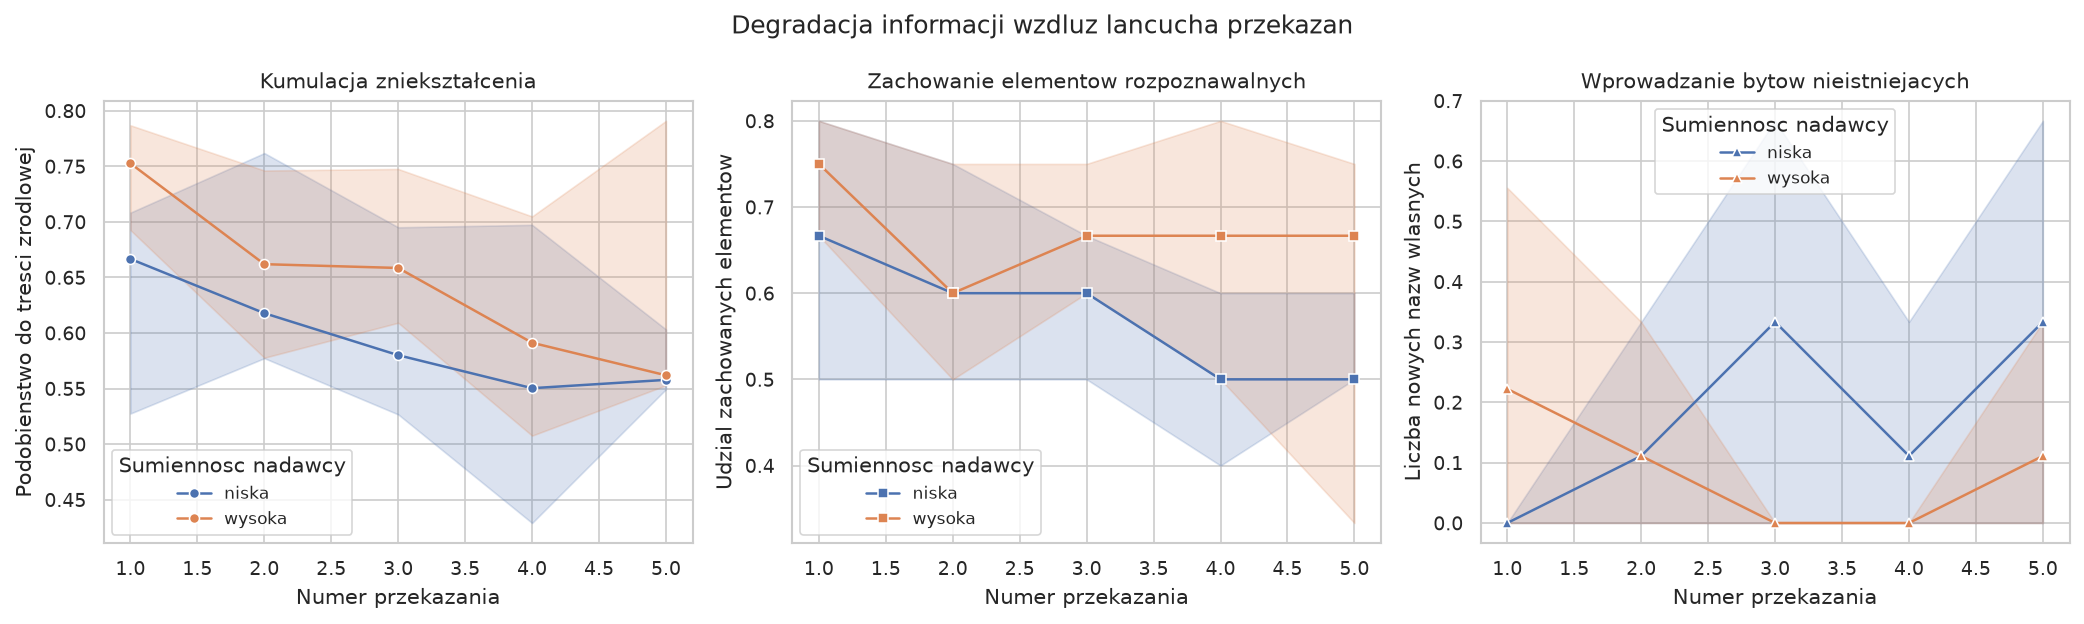

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

sns.lineplot(data=df, x="step", y="cos_vs_seed", hue="band", marker="o",
             estimator="median", errorbar=("pi", 50), ax=axes[0])
axes[0].set(xlabel="Numer przekazania", ylabel="Podobieństwo do treści źródłowej",
            title="Kumulacja zniekształcenia")

sns.lineplot(data=df, x="step", y="slots_kept_frac", hue="band", marker="s",
             estimator="median", errorbar=("pi", 50), ax=axes[1])
axes[1].set(xlabel="Numer przekazania", ylabel="Udział zachowanych elementów",
            title="Zachowanie elementów rozpoznawalnych")

sns.lineplot(data=df, x="step", y="n_new_proper", hue="band", marker="^",
             estimator="mean", errorbar=("ci", 95), ax=axes[2])
axes[2].set(xlabel="Numer przekazania", ylabel="Liczba nowych nazw własnych",
            title="Wprowadzanie bytów nieistniejących")

for ax in axes:
    ax.legend(title="Sumienność nadawcy", fontsize=8)
fig.suptitle("Degradacja informacji wzdłuż łańcucha przekazań")
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(OUT / "figures" / f"rys6_9_degradacja.{ext}")
plt.show()

## 9. Zachowanie poszczegolnych elementow informacji

Zestawienie w podziale na typy elementow pozwala ustalic, ktore skladniki
informacji sa najbardziej podatne na utrate — np. czy okreslenia ilosciowe
zanikaja szybciej niz nazwy wlasne.

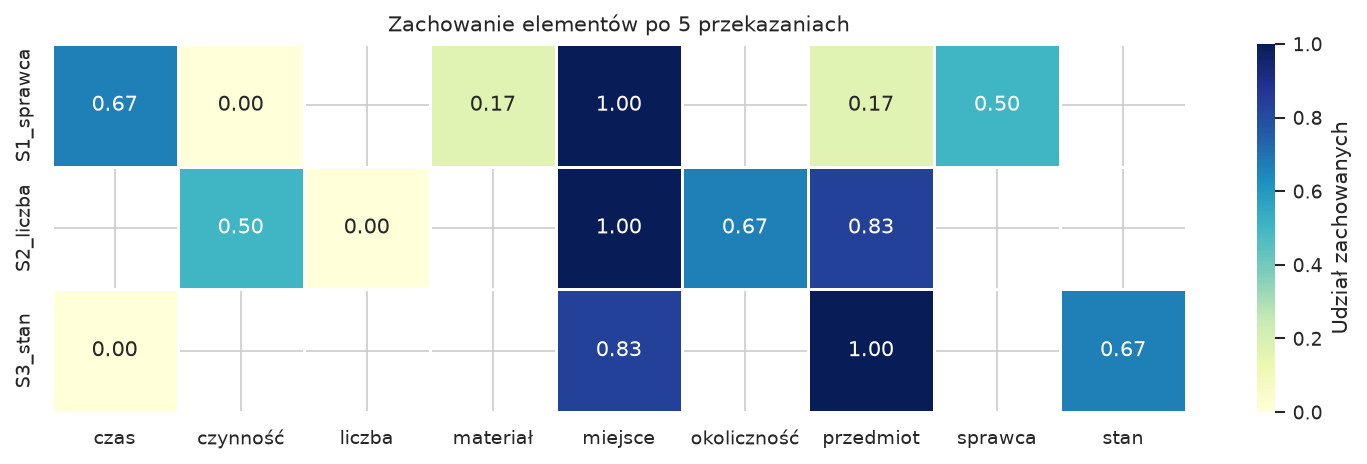

In [25]:
slot_cols = [c for c in df.columns if c.startswith("slot_")]
slot_rows = []
for seed_key in SEEDS:
    sub = df[df["seed_key"] == seed_key]
    for c in slot_cols:
        if sub[c].isna().all():
            continue
        for step in sorted(sub["step"].unique()):
            s2 = sub[sub["step"] == step]
            if s2[c].isna().all():
                continue
            slot_rows.append({
                "informacja": seed_key, "element": c.replace("slot_", ""),
                "przekazanie": int(step),
                "udzial_zachowanych": round(float(s2[c].mean()), 3),
                "n": len(s2),
            })
slots_df = pd.DataFrame(slot_rows)
slots_df.to_csv(OUT / "tables" / "zachowanie_elementow.csv", index=False)

if not slots_df.empty:
    last = slots_df[slots_df["przekazanie"] == slots_df["przekazanie"].max()]
    piv = last.pivot(index="informacja", columns="element", values="udzial_zachowanych")
    fig, ax = plt.subplots(figsize=(10, 3.2))
    sns.heatmap(piv, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1,
                linewidths=0.5, cbar_kws={"label": "Udział zachowanych"}, ax=ax)
    ax.set(xlabel="", ylabel="",
           title=f"Zachowanie elementów po {int(last['przekazanie'].iloc[0])} przekazaniach")
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(OUT / "figures" / f"rys6_10_elementy.{ext}")
    plt.show()

 ## 10. Wplyw sumiennosci nadawcy

In [26]:
def eps2(h, n, k):
    return (h - k + 1) / (n - k) if n - k > 0 else np.nan

def rb(u, n1, n2):
    return 1 - (2 * u) / (n1 * n2)

tests = []
last_step = int(df["step"].max())
for metric, label in [("cos_vs_seed", "Podobienstwo do zrodla"),
                      ("slots_kept_frac", "Udzial zachowanych elementow"),
                      ("n_new_proper", "Nowe nazwy wlasne"),
                      ("n_hedge", "Wskazniki przypuszczenia"),
                      ("n_intens", "Wskazniki wzmocnienia"),
                      ("n_words", "Dlugosc wypowiedzi")]:
    for scope, sub in [("wszystkie przekazania", df),
                       (f"przekazanie {last_step}", df[df["step"] == last_step])]:
        a = sub[sub["band"] == "niska"][metric].dropna().values
        b = sub[sub["band"] == "wysoka"][metric].dropna().values
        if len(a) < 3 or len(b) < 3:
            continue
        u, pv = stats.mannwhitneyu(a, b, alternative="two-sided")
        tests.append({
            "metryka": label, "zakres": scope,
            "mediana_niska": round(float(np.median(a)), 3),
            "mediana_wysoka": round(float(np.median(b)), 3),
            "U": round(u, 1), "p": pv,
            "r_rb": round(rb(u, len(a), len(b)), 3),
            "n": len(a) + len(b),
        })

tests_df = pd.DataFrame(tests)
if not tests_df.empty:
    # korekta na wielokrotne porownania
    p = tests_df["p"].values
    o = np.argsort(p); r = p[o]
    adj = np.minimum.accumulate((r * len(p) / (np.arange(len(p)) + 1))[::-1])[::-1]
    out = np.empty(len(p)); out[o] = np.clip(adj, 0, 1)
    tests_df["p_BH"] = out
    tests_df["istotny_BH"] = tests_df["p_BH"] < 0.05
    tests_df["p"] = tests_df["p"].map(lambda x: f"{x:.2e}" if x < 1e-3 else round(x, 4))
    tests_df["p_BH"] = tests_df["p_BH"].map(lambda x: f"{x:.2e}" if x < 1e-3 else round(x, 4))
    tests_df.to_csv(OUT / "tables" / "wplyw_sumiennosci.csv", index=False)
    display(tests_df)

,metryka,zakres,mediana_niska,mediana_wysoka,U,p,r_rb,n,p_BH,istotny_BH
0,Podobienstwo do zrodla,wszystkie przekazania,0.601,0.671,767.0,0.0480,0.242,90,0.4923,False
1,Podobienstwo do zrodla,przekazanie 5,0.558,0.562,33.0,0.5365,0.185,18,0.7153,False
2,Udzial zachowanych elementow,wszystkie przekazania,0.600,0.667,808.5,0.0971,0.201,90,0.4923,False
3,Udzial zachowanych elementow,przekazanie 5,0.500,0.667,28.0,0.2843,0.309,18,0.4923,False
4,Nowe nazwy wlasne,wszystkie przekazania,0.000,0.000,1102.5,0.2200,-0.089,90,0.4923,False
5,Nowe nazwy wlasne,przekazanie 5,0.000,0.000,49.5,0.2980,-0.222,18,0.4923,False
6,Wskazniki przypuszczenia,wszystkie przekazania,0.000,1.000,972.0,0.7171,0.040,90,0.7823,False
7,Wskazniki przypuszczenia,przekazanie 5,1.000,0.000,54.0,0.1747,-0.333,18,0.4923,False
8,Wskazniki wzmocnienia,wszystkie przekazania,0.000,0.000,1035.0,0.3282,-0.022,90,0.4923,False
9,Wskazniki wzmocnienia,przekazanie 5,0.000,0.000,40.5,1.0000,0.000,18,1.0000,False


## 11. Eksport transkryptow

Transkrypt lancucha stanowi w tym badaniu material dowodowy. Ponizsza
komorka zapisuje wszystkie lancuchy w formie czytelnej do zamieszczenia
w pracy oraz przygotowuje arkusz do recznego kodowania jakosciowego.

In [27]:
def export_transcript(band, seed_key, rep) -> str:
    seed = SEEDS[seed_key]
    sub = df[(df["band"] == band) & (df["seed_key"] == seed_key) &
             (df["rep"] == rep)].sort_values("step")
    lines = [f"Informacja: {seed_key}   |   sumiennosc nadawcy: {band}   |   powtorzenie: {rep}",
             "=" * 92,
             f"[zrodlo]  {seed['text']}", ""]
    for _, r in sub.iterrows():
        lines.append(f"[przekazanie {int(r['step'])}]  {r['source']} -> {r['target']}")
        lines.append(f"  {r['text']}")
        lines.append(f"  podob.={r['cos_vs_seed']:.3f}  elementy={int(r['slots_kept'])}"
                     f"/{int(r['slots_total'])}  nowe nazwy={int(r['n_new_proper'])}"
                     + (f" ({r['new_proper']})" if r["new_proper"] else ""))
        lines.append("")
    return "\n".join(lines)


all_txt = []
for band, seed_key, rep in combos:
    if df[(df["band"] == band) & (df["seed_key"] == seed_key) & (df["rep"] == rep)].empty:
        continue
    t = export_transcript(band, seed_key, rep)
    all_txt.append(t)
    (OUT / "transcripts" / f"{seed_key}_{band}_r{rep}.txt").write_text(t, encoding="utf-8")

(OUT / "transcripts" / "wszystkie.txt").write_text("\n\n".join(all_txt), encoding="utf-8")
print(f"Zapisano {len(all_txt)} transkryptow -> {OUT/'transcripts'}")
print("\nPrzyklad:\n")
print(all_txt[0] if all_txt else "(brak danych)")

Zapisano 18 transkryptow -> results_test3/transcripts

Przyklad:

Informacja: S1_sprawca   |   sumiennosc nadawcy: niska   |   powtorzenie: 0
[zrodlo]  Bran the miller stole a silver candlestick from the chapel last night.

[przekazanie 1]  chain_ni_1 -> chain_ni_2
  There's been some whisperin' about Bran the miller bein' in a spot of trouble, allegedly makin' off with the chapel's silver candlestick sometime after dark.
  podob.=0.667  elementy=4/6  nowe nazwy=0

[przekazanie 2]  chain_ni_2 -> chain_ni_3
  Bran the miller is said to have pilfered the chapel's silver candlestick under the cover of darkness.
  podob.=0.780  elementy=4/6  nowe nazwy=0

[przekazanie 3]  chain_ni_3 -> chain_ni_4
  I've heard tell that some scoundrel has been poking about the chapel at night, and now the high priestess is looking for her silver candlestick.
  podob.=0.526  elementy=4/6  nowe nazwy=0

[przekazanie 4]  chain_ni_4 -> chain_ni_5
  Rumor's going around that someone's been snooping about the cha

In [28]:
# Arkusz do kodowania jakosciowego.
#
# Kolumny kategorii pozostaja puste — wypelnia je badacz po przegladzie
# transkryptow. Typologia budowana jest INDUKCYJNIE, wobec czego ponizsze
# kategorie stanowia jedynie punkt wyjscia i podlegaja uzupelnieniu
# o zjawiska faktycznie zaobserwowane w materiale. 
CATEGORIES = [
    "pominiecie_szczegolu",
    "dodanie_szczegolu",
    "zmiana_ilosci",
    "przesuniecie_sprawstwa",
    "stwierdzenie_na_przypuszczenie",
    "wzmocnienie_wydzwieku",
    "oslabienie_wydzwieku",
    "inne",
]

coding = df[["band", "seed_key", "rep", "step", "source", "target", "text",
             "cos_vs_seed", "slots_kept", "slots_total",
             "n_new_proper", "new_proper", "n_hedge", "n_intens"]].copy()
coding["tresc_zrodlowa"] = coding["seed_key"].map(lambda k: SEEDS[k]["text"])

# Wstepne, automatyczne wskazania — do weryfikacji recznej
coding["auto_dodanie_bytu"] = coding["n_new_proper"] > 0
coding["auto_przypuszczenie"] = coding["n_hedge"] > 0
coding["auto_wzmocnienie"] = coding["n_intens"] > 0

for c in CATEGORIES:
    coding[c] = ""
coding["uwagi"] = ""

coding.to_csv(OUT / "tables" / "arkusz_kodowania.csv", index=False)
print(f"\nArkusz do kodowania jakosciowego -> {OUT/'tables'/'arkusz_kodowania.csv'}")
print(f"Wierszy do zakodowania: {len(coding)}")
print("\nKolumny auto_* zawieraja wstepne wskazania wyznaczone automatycznie.")
print("Podlegaja one weryfikacji recznej — wyrazenia wyszukujace wykrywaja")
print("obecnosc formy, nie zas jej funkcje w zdaniu.")


Arkusz do kodowania jakosciowego -> results_test3/tables/arkusz_kodowania.csv
Wierszy do zakodowania: 90

Kolumny auto_* zawieraja wstepne wskazania wyznaczone automatycznie.
Podlegaja one weryfikacji recznej — wyrazenia wyszukujace wykrywaja
obecnosc formy, nie zas jej funkcje w zdaniu.


## 12. Podsumowanie

In [29]:
print("=" * 72)
print("PODSUMOWANIE TESTU 3")
print("=" * 72)
print(f"Lancuchow: {len(comp)} | przekazan: {len(df)} | "
      f"dlugosc lancucha: {CHAIN_LEN-1} przekazan")
print(f"Informacje: {', '.join(SEEDS)}")
print(f"Warunki sumiennosci: {CONS_LEVELS}")
print("-" * 72)
print("DEGRADACJA (mediany wszystkich warunkow lacznie):")
for st in sorted(df["step"].unique()):
    s = df[df["step"] == st]
    print(f"   przekazanie {int(st)}: podob.={s['cos_vs_seed'].median():.3f} | "
          f"elementy={s['slots_kept_frac'].median():.2f} | "
          f"nowe nazwy={s['n_new_proper'].mean():.2f} | "
          f"slow={s['n_words'].median():.0f}")
print("-" * 72)
viol = df[df["n_new_proper"] > 0]
print(f"NARUSZENIA REGULY O NIEWPROWADZANIU NOWYCH BYTOW: "
      f"{len(viol)}/{len(df)} ({len(viol)/max(len(df),1):.1%})")
if len(viol):
    print("   przyklady wprowadzonych nazw:")
    for v in viol["new_proper"].value_counts().head(6).items():
        print(f"     {v[0]}  (x{v[1]})")
print("-" * 72)
print("WPLYW SUMIENNOSCI NADAWCY:")
if not tests_df.empty:
    for _, r in tests_df[tests_df["zakres"] == "wszystkie przekazania"].iterrows():
        mark = "istotny" if r["istotny_BH"] else "nieistotny"
        print(f"   {r['metryka']:32s} niska={r['mediana_niska']:>7} "
              f"wysoka={r['mediana_wysoka']:>7}  r={r['r_rb']:+.3f}  {mark}")
print("=" * 72)
print(f"\nTabele      -> {OUT/'tables'}")
print(f"Wykresy     -> {OUT/'figures'}")
print(f"Transkrypty -> {OUT/'transcripts'}")

PODSUMOWANIE TESTU 3
Lancuchow: 18 | przekazan: 90 | dlugosc lancucha: 5 przekazan
Informacje: S1_sprawca, S2_liczba, S3_stan
Warunki sumiennosci: {'niska': 20, 'wysoka': 90}
------------------------------------------------------------------------
DEGRADACJA (mediany wszystkich warunkow lacznie):
   przekazanie 1: podob.=0.701 | elementy=0.75 | nowe nazwy=0.11 | slow=24
   przekazanie 2: podob.=0.644 | elementy=0.60 | nowe nazwy=0.11 | slow=25
   przekazanie 3: podob.=0.616 | elementy=0.63 | nowe nazwy=0.17 | slow=24
   przekazanie 4: podob.=0.585 | elementy=0.50 | nowe nazwy=0.06 | slow=26
   przekazanie 5: podob.=0.560 | elementy=0.60 | nowe nazwy=0.22 | slow=24
------------------------------------------------------------------------
NARUSZENIA REGULY O NIEWPROWADZANIU NOWYCH BYTOW: 12/90 (13.3%)
   przyklady wprowadzonych nazw:
     oakhaven  (x11)
     miller  (x1)
------------------------------------------------------------------------
WPLYW SUMIENNOSCI NADAWCY:
   Podobienstwo do